# Basic Idea

The model heirarchy (I think) is something like:

Everyone has a common dispersion (r)

Every condition has a common Beta distribution (alpha, beta)

Every individual has a probability sampled from their relevant Beta distribution.

Every cell has a size factor we can pre-compute (s)

So we get something like 

$$
p \sim B(\alpha, \beta)
$$
$$
X \sim NB(r \cdot s, p)
$$

We can then ask questions about whether two groups beta distributions show very different distributions.
In this case, we'll do something people are talking about recently, PLIN2 expression in immune cells (in this case, we have macrophages in the CPE).

In [39]:
import scanpy as sc

adata = sc.read_h5ad("/Users/jameshaberberger/GitHub/choroid-plexus/new_annotations.h5ad")
adata = adata[adata.obs["Cell.Subtype"].eq("Macrophage")].copy()

In [57]:
df = adata.obs \
    .assign(expression = adata[:, "PLIN2"].X.todense().reshape(-1).tolist()[0]) \
    .assign(size_factor = adata.X.sum(axis=1).reshape(-1).tolist()[0]) \
    .eval("size_factor = size_factor / size_factor.mean()") \
    [["orig.ident", "cogdx", "expression", "size_factor"]]

df["cogdx"].replace({1: 0, 2: 1, 4: 2}, inplace=True)

/var/folders/2n/j06nrn2n7r524t776sngh0xr0000gr/T/ipykernel_95617/976806447.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["cogdx"].replace({1: 0, 2: 1, 4: 2}, inplace=True)


In [66]:
import pyro
import pyro.distributions as dist
import torch
from pyro.nn import PyroModule
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import ClippedAdam

y = torch.tensor(df["expression"]).float()
size_factors = torch.tensor(df["size_factor"]).float()
individual = torch.tensor(df["orig.ident"].cat.codes).long()
group = torch.tensor(df["cogdx"]).long()

/var/folders/2n/j06nrn2n7r524t776sngh0xr0000gr/T/ipykernel_95617/228200120.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y = torch.tensor(df["expression"]).float()
/var/folders/2n/j06nrn2n7r524t776sngh0xr0000gr/T/ipykernel_95617/228200120.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  size_factors = torch.tensor(df["size_factor"]).float()
/var/folders/2n/j06nrn2n7r524t776sngh0xr0000gr/T/ipykernel_95617/228200120.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access

In [115]:
pyro.clear_param_store()

def model(y, size_factors, individual, group):
    C = y.shape[0]              # number of cells
    N = group.shape[0]          # number of individuals
    G = int(group.max().item()) + 1

    alpha = pyro.sample("alpha", dist.Gamma(torch.ones(G) * 2, torch.ones(G)).to_event(1))
    beta  = pyro.sample("beta",  dist.Gamma(torch.ones(G) * 2, torch.ones(G)).to_event(1))
    r = pyro.sample("r", dist.Gamma(2.0, 1.0))

    with pyro.plate("individuals", N):
        a_i = alpha[group]
        b_i = beta[group]
        p_i = pyro.sample("p", dist.Beta(a_i, b_i))

    p_c = p_i[individual]
    mu = (r * (1 - p_c) / p_c) * size_factors

    with pyro.plate("cells", C):
        pyro.sample("obs", dist.NegativeBinomial(total_count=r, logits=(mu / r).log()), obs=y)


def guide(y, size_factors, individual, group):
    N = group.shape[0]
    G = int(group.max().item()) + 1

    # Group-level posterior on alpha, beta
    log_alpha_loc = pyro.param("log_alpha_loc", torch.zeros(G))
    log_alpha_scale = pyro.param("log_alpha_scale", torch.ones(G) * 0.1, constraint=dist.constraints.positive)
    log_beta_loc = pyro.param("log_beta_loc", torch.zeros(G))
    log_beta_scale = pyro.param("log_beta_scale", torch.ones(G) * 0.1, constraint=dist.constraints.positive)

    pyro.sample("alpha", dist.LogNormal(log_alpha_loc, log_alpha_scale).to_event(1))
    pyro.sample("beta",  dist.LogNormal(log_beta_loc, log_beta_scale).to_event(1))


    # Global r
    log_r_loc = pyro.param("log_r_loc", torch.tensor(0.0))
    log_r_scale = pyro.param("log_r_scale", torch.tensor(0.1), constraint=dist.constraints.positive)
    pyro.sample("r", dist.LogNormal(log_r_loc, log_r_scale))

    # Per-individual p_i using logistic-normal
    logit_p_loc = pyro.param("logit_p_loc", torch.zeros(N))
    logit_p_scale = pyro.param("logit_p_scale", torch.ones(N) * 0.1, constraint=dist.constraints.positive)
    with pyro.plate("individuals", N):
        pyro.sample("p", dist.TransformedDistribution(
            dist.Normal(logit_p_loc, logit_p_scale),
            [dist.transforms.SigmoidTransform()]
        ))

# ----------------------------
# SVI training loop
# ----------------------------
pyro.clear_param_store()
optimizer = ClippedAdam({'lr': 1e-3, 'clip_norm': 10.0})
elbo = Trace_ELBO()
svi = SVI(model, guide, optimizer, loss=elbo)

losses = []
for step in range(10_000):
    loss = svi.step(y, size_factors, individual, group)

    losses.append(loss)
    if step % 1000 == 0:
        print(f"Step {step} - ELBO: {loss:.2f}")



Step 0 - ELBO: 62378.10
Step 1000 - ELBO: 29510.88
Step 2000 - ELBO: 14802.55
Step 3000 - ELBO: 13270.88
Step 4000 - ELBO: 13188.86
Step 5000 - ELBO: 13178.84
Step 6000 - ELBO: 13162.34
Step 7000 - ELBO: 13166.38
Step 8000 - ELBO: 13166.94
Step 9000 - ELBO: 13168.70


Just to show our sampling has converged

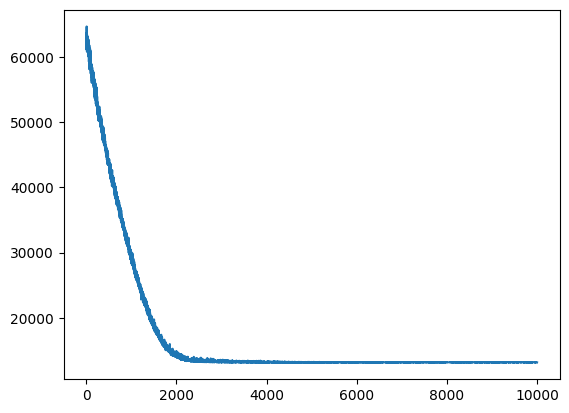

In [116]:
import matplotlib.pyplot as plt
plt.plot(losses)

We can return our estimates.

In [117]:

# Return final parameter estimates
for k, v in {name: pyro.get_param_store()[name].detach().clone() for name in pyro.get_param_store()}.items():
    if "logit_p" in k:
        break
    print(f"{k}: {v.tolist()}")

log_alpha_loc: [1.621646523475647, 1.677664875984192, 1.6392834186553955]
log_alpha_scale: [0.007929098792374134, 0.006551989354193211, 0.007511656731367111]
log_beta_loc: [1.5558863878250122, 1.671435832977295, 1.6498184204101562]
log_beta_scale: [0.007865398190915585, 0.006804374512284994, 0.00767882727086544]
log_r_loc: -0.3421134054660797
log_r_scale: 0.015284357592463493


To determine if there is a difference, lets see if the parameters we infer for the alpha and beta of each of these groups distribute very differently from one another.

In [113]:
import torch

# Assume you have learned log_alpha_loc, log_alpha_scale, etc. (G=3)
G = len(pyro.param("log_alpha_loc"))
S = 10000  # num posterior samples

alpha_samples = torch.exp(torch.randn(S, G) * pyro.param("log_alpha_scale") + pyro.param("log_alpha_loc"))
beta_samples  = torch.exp(torch.randn(S, G) * pyro.param("log_beta_scale")  + pyro.param("log_beta_loc"))

# Optional: sample full Beta distributions from each group
from torch.distributions import Beta
beta_dists = [Beta(alpha_samples[:,g], beta_samples[:,g]) for g in range(G)]

# Compare samples across groups (e.g. group 0 vs 1)
diff = (beta_dists[0].mean - beta_dists[2].mean)


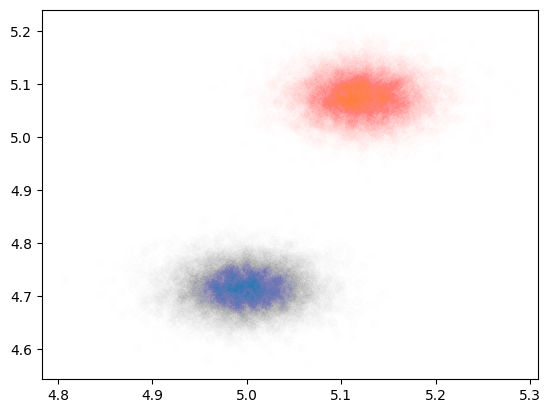

In [ ]:
plt.scatter(
    x=alpha_samples[:,0].detach(), 
    y=beta_samples[:, 0].detach(),
    alpha=0.005
)

plt.scatter(
    x=alpha_samples[:,1].detach(), 
    y=beta_samples[:,1].detach(),
    alpha=0.005
)

plt.scatter(
    x=alpha_samples[:,2].detach(), 
    y=beta_samples[:,2].detach(),
    alpha=0.005
)

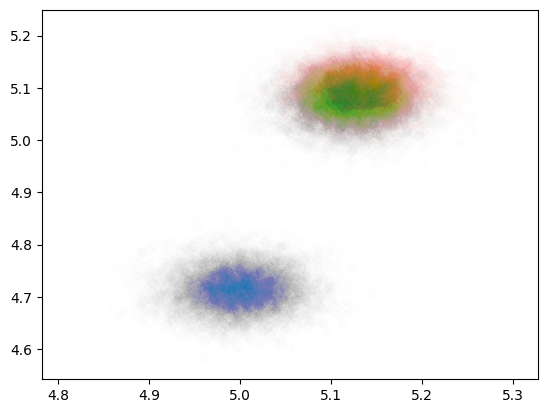

In [118]:
plt.scatter(
    x=alpha_samples[:,0].detach(), 
    y=beta_samples[:, 0].detach(),
    alpha=0.005
)

plt.scatter(
    x=alpha_samples[:,1].detach(), 
    y=beta_samples[:,1].detach(),
    alpha=0.005
)

plt.scatter(
    x=alpha_samples[:,2].detach(), 
    y=beta_samples[:,2].detach(),
    alpha=0.005
)

This gives us pretty good evidence that PLIN2 Expression differs between control and experimental groups. Lets try another gene, transthyretin.

In [87]:
y = torch.tensor(adata[:, "APP"].X.todense().reshape(-1).tolist()[0]).float()   

In [89]:
# ----------------------------
# SVI training loop
# ----------------------------
pyro.clear_param_store()
optimizer = ClippedAdam({'lr': 1e-3, 'clip_norm': 10.0})
elbo = Trace_ELBO()
svi = SVI(model, guide, optimizer, loss=elbo)

losses = []
for step in range(10_000):
    loss = svi.step(y, size_factors, individual, group)

    losses.append(loss)
    if step % 100 == 0:
        print(f"Step {step} - ELBO: {loss:.2f}")


Step 0 - ELBO: 62824.71
Step 100 - ELBO: 58556.27
Step 200 - ELBO: 54500.48
Step 300 - ELBO: 51268.80
Step 400 - ELBO: 47585.70
Step 500 - ELBO: 42850.13
Step 600 - ELBO: 40233.34
Step 700 - ELBO: 37580.71
Step 800 - ELBO: 34270.95
Step 900 - ELBO: 32021.01
Step 1000 - ELBO: 29023.39
Step 1100 - ELBO: 26417.26
Step 1200 - ELBO: 24840.64
Step 1300 - ELBO: 21990.85
Step 1400 - ELBO: 20124.43
Step 1500 - ELBO: 18631.08
Step 1600 - ELBO: 18504.47
Step 1700 - ELBO: 16465.14
Step 1800 - ELBO: 15239.68
Step 1900 - ELBO: 14911.87
Step 2000 - ELBO: 14135.89
Step 2100 - ELBO: 13860.80
Step 2200 - ELBO: 13788.13
Step 2300 - ELBO: 13528.69
Step 2400 - ELBO: 13421.40
Step 2500 - ELBO: 13598.47
Step 2600 - ELBO: 13461.83
Step 2700 - ELBO: 13407.00
Step 2800 - ELBO: 13232.42
Step 2900 - ELBO: 13269.47
Step 3000 - ELBO: 13275.71
Step 3100 - ELBO: 13239.80
Step 3200 - ELBO: 13215.08
Step 3300 - ELBO: 13206.51
Step 3400 - ELBO: 13238.43
Step 3500 - ELBO: 13241.87
Step 3600 - ELBO: 13228.56
Step 3700 - E

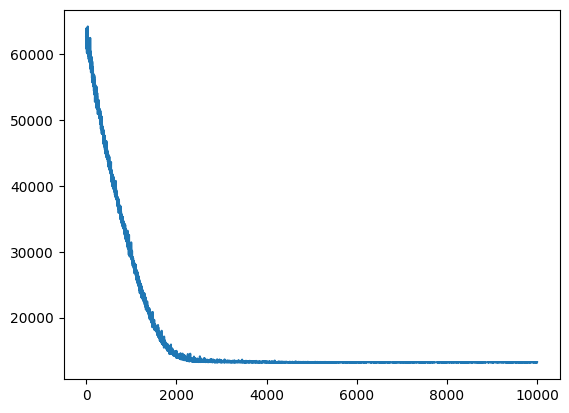

In [90]:
import matplotlib.pyplot as plt
plt.plot(losses)

In [91]:
# Return final parameter estimates
for k, v in {name: pyro.get_param_store()[name].detach().clone() for name in pyro.get_param_store()}.items():
    if "logit_p" in k:
        break
    print(f"{k}: {v.tolist()}")

log_alpha_loc: [1.5995138883590698, 1.6404091119766235, 1.6154851913452148]
log_alpha_scale: [0.00815712008625269, 0.00688508152961731, 0.007552715949714184]
log_beta_loc: [1.5327777862548828, 1.634015679359436, 1.6170942783355713]
log_beta_scale: [0.007973668165504932, 0.006944950670003891, 0.007421212736517191]
log_r_loc: -0.3421166241168976
log_r_scale: 0.015230374410748482


To determine if there is a difference, lets see if the parameters we infer for the alpha and beta of each of these groups distribute very differently from one another.

In [ ]:
import torch

# Assume you have learned log_alpha_loc, log_alpha_scale, etc. (G=3)
G = len(pyro.param("log_alpha_loc"))
S = 10000  # num posterior samples

alpha_samples = torch.exp(torch.randn(S, G) * pyro.param("log_alpha_scale") + pyro.param("log_alpha_loc"))
beta_samples  = torch.exp(torch.randn(S, G) * pyro.param("log_beta_scale")  + pyro.param("log_beta_loc"))

# Optional: sample full Beta distributions from each group
from torch.distributions import Beta
beta_dists = [Beta(alpha_samples[:,g], beta_samples[:,g]) for g in range(G)]

# Compare samples across groups (e.g. group 0 vs 1)
diff = (beta_dists[0].mean - beta_dists[2].mean)

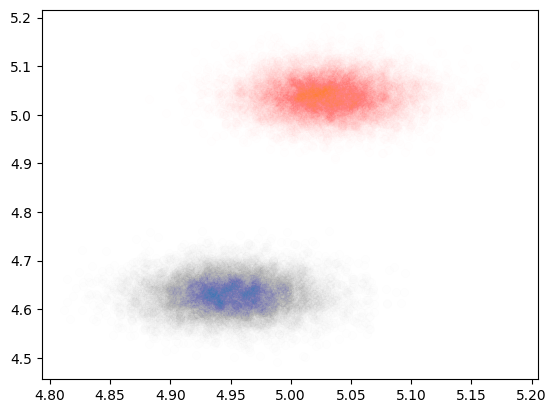

In [93]:
plt.scatter(
    x=alpha_samples[:,0].detach(), 
    y=beta_samples[:, 0].detach(),
    alpha=0.005
)

plt.scatter(
    x=alpha_samples[:,2].detach(), 
    y=beta_samples[:, 2].detach(),
    alpha=0.005
)

We get even stronger evidence of differences in TTR, which is also cool.